In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn import preprocessing
import matplotlib.pyplot as plt

#loading the data

In [2]:
df = pd.read_csv('Audiobooks_data.csv',delimiter =',')

#creating input and target

In [3]:
input_data = df.iloc[:,1:-1]
target_data = df.iloc[:,-1]

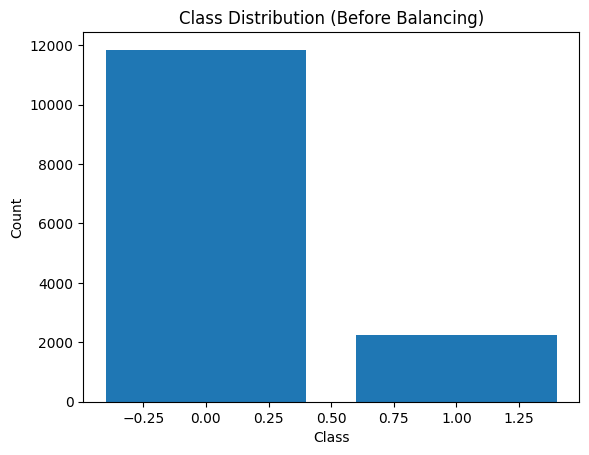

In [4]:
unique, counts = np.unique(target_data, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution (Before Balancing)")
plt.show()


##balancing the data

In [5]:
zero_counter = 0
indices_to_remove = []
one_data_all = np.sum(target_data)

for i in range(target_data.shape[0]):
  if target_data[i] == 0:
    zero_counter += 1
    if zero_counter > one_data_all:
      indices_to_remove.append(i)
balanced_input_data =  np.delete(input_data,indices_to_remove,axis = 0)
balanced_target_data = np.delete(target_data,indices_to_remove,axis = 0)

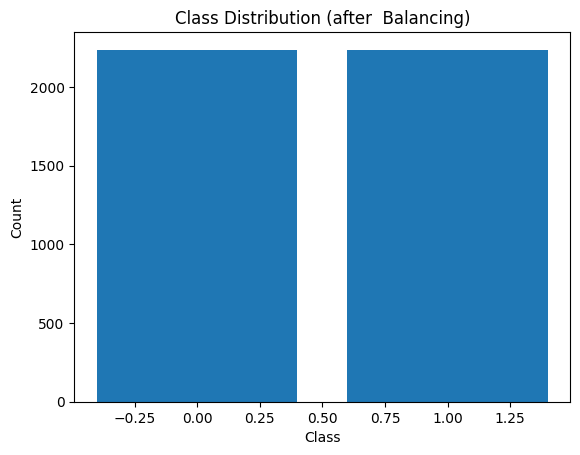

In [6]:
unique, counts = np.unique(balanced_target_data, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution (after  Balancing)")
plt.show()

# shuffling the data

In [7]:
indices = np.arange(balanced_target_data.shape[0])
np.random.shuffle(indices)

input_data = balanced_input_data[indices]
target_data = balanced_target_data[indices]

#scaling the data

In [8]:
scaled_input = preprocessing.scale(input_data)

## splitting into train,test and validation

In [9]:
sample_count = int(target_data.shape[0])

train_count = int(0.8*(sample_count))
validation_count = int(0.1*(sample_count))
test_count = sample_count-train_count-validation_count

train_input_data = scaled_input[:train_count]
train_target_data = target_data[:train_count]

validation_input_data = scaled_input[train_count:validation_count+train_count]
validation_target_data = target_data[train_count:validation_count +train_count]

test_input_data = scaled_input[validation_count+train_count:]
test_target_data = target_data[validation_count+train_count:]

In [10]:
hidden_layer_size = 50
output_size = 2

model = tf.keras.Sequential([
    tf.keras.layers.Dense(hidden_layer_size,activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size,activation='relu'),
    tf.keras.layers.Dense(output_size,activation = 'softmax')
])


## compiling the model

In [11]:
batch_size = 100
max_epochs = 100
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])

## fitting the model

In [12]:
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)
history = model.fit(train_input_data,train_target_data,
          validation_data = (validation_input_data,validation_target_data),
          batch_size = batch_size,
          verbose = 2,
          epochs = max_epochs,
          callbacks = [early_stopping]
          )

Epoch 1/100
36/36 - 3s - 70ms/step - accuracy: 0.6873 - loss: 0.5704 - val_accuracy: 0.7338 - val_loss: 0.4999
Epoch 2/100
36/36 - 0s - 8ms/step - accuracy: 0.7547 - loss: 0.4650 - val_accuracy: 0.7539 - val_loss: 0.4297
Epoch 3/100
36/36 - 0s - 5ms/step - accuracy: 0.7751 - loss: 0.4181 - val_accuracy: 0.7987 - val_loss: 0.3936
Epoch 4/100
36/36 - 0s - 5ms/step - accuracy: 0.7910 - loss: 0.3927 - val_accuracy: 0.7919 - val_loss: 0.3766
Epoch 5/100
36/36 - 0s - 5ms/step - accuracy: 0.7991 - loss: 0.3761 - val_accuracy: 0.8009 - val_loss: 0.3555
Epoch 6/100
36/36 - 0s - 5ms/step - accuracy: 0.8047 - loss: 0.3632 - val_accuracy: 0.8143 - val_loss: 0.3494
Epoch 7/100
36/36 - 0s - 6ms/step - accuracy: 0.8092 - loss: 0.3576 - val_accuracy: 0.8121 - val_loss: 0.3397
Epoch 8/100
36/36 - 0s - 6ms/step - accuracy: 0.8100 - loss: 0.3534 - val_accuracy: 0.8188 - val_loss: 0.3396
Epoch 9/100
36/36 - 0s - 5ms/step - accuracy: 0.8097 - loss: 0.3462 - val_accuracy: 0.8054 - val_loss: 0.3479
Epoch 10/

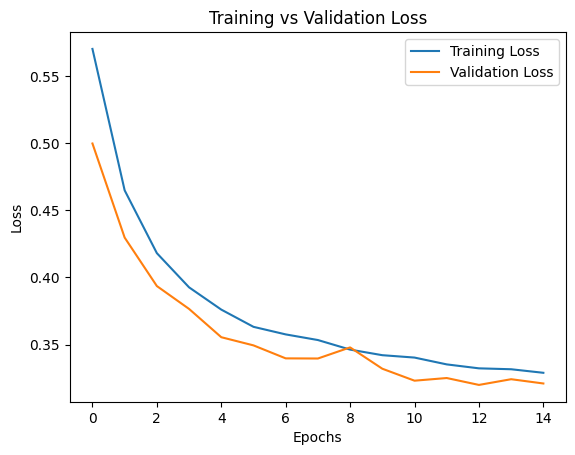

In [13]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


## checking accuracy the model

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


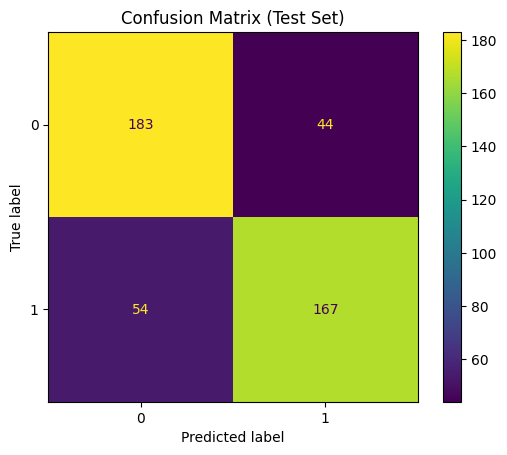

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict probabilities
y_pred_probs = model.predict(test_input_data)

# Convert softmax probabilities to class labels (0 or 1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(test_target_data, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (Test Set)")
plt.show()



In [15]:
y_true = test_target_data
y_pred = model.predict(test_input_data)

y_pred = (y_pred > 0.5).astype(int)
y_pred_labels = np.argmax(y_pred, axis=1)
print(y_pred_labels)

from sklearn.metrics import recall_score
recall = recall_score(y_true, y_pred_labels)
print("Recall on test set:", recall)

from sklearn.metrics import precision_score

precision = precision_score(y_true, y_pred_labels)
print("Precision:", precision)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
[1 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 0 1 1 0 0 1 0 1 1 1
 0 1 0 1 0 1 0 0 0 0 1 0 1 1 1 0 0 1 0 0 1 1 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0
 0 1 0 1 0 0 0 1 1 0 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0 0 0 0 1 0 1 0 1 0
 0 1 1 0 1 1 1 0 1 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 0 1 1 0 1 1 0 0 1 0 0 0 1 1 0 0 0 0 1 1 1 0 1 0 0 0 0 1 1 0 0 0 0 1 0 1 0
 0 1 0 0 1 1 1 1 1 0 0 0 0 0 1 0 1 0 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1
 1 0 1 0 1 0 0 1 0 1 1 0 0 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 0 1 0 0 0 1 0 0
 1 1 1 1 1 1 0 0 1 0 1 0 1 1 1 0 1 1 0 0 0 0 0 1 0 1 1 1 0 0 1 0 0 0 1 1 0
 1 1 1 0 1 1 1 1 1 1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 0
 1 0 0 1 0 0 0 0 1 1 0 0 1 1 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 0 0 1 1 1 1 0
 0 0 0 1 0 1 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 1 1 1 0 0 1 0 1 1 0 1 0 1 0
 0 0 1 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 0
 1 0 0 1]
Recall on test set: 0.755656108597285
Precision: 0

In [17]:
print(y_pred)

[[0 1]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [1 0]

In [18]:
test_loss,test_accuracy = model.evaluate(test_input_data,test_target_data)
test_loss,test_accuracy

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7964 - loss: 0.3461 


(0.355898380279541, 0.78125)